# 01 - Schema profile and threshold evidence

Purpose: decide what belongs in the data contract, and justify every
threshold in it with a distribution rather than an assertion.

This notebook does not re-implement the pipeline. It calls the same
contract and profiler the pipeline uses, so anything concluded here is
directly transferable into `contracts/trips.yml`.


In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from taxi.config import load_settings
from taxi.contract import Contract
from taxi.core import duck
from taxi.core.months import Month

settings = load_settings(ROOT / 'configs' / 'settings.yml')
contract = Contract.load(settings.contract_path)
print('contract', contract.version, contract.fingerprint)


contract 1.0.0 1.0.0+be8b35e8b06fd716


## 1. What the source file actually contains

TLC releases are not uniform: column casing drifts, optional columns
appear and disappear, physical types change between months. Start from
what is in the file, not from what the documentation says.


In [2]:
from taxi.acquisition.sources import local_path

month = Month(2025, 1)
path = local_path(settings, month)
print(path, path.exists())

with duck.connect(settings) as con:
    actual = duck.describe(con, duck.scan(path, hive=False))
for name, dtype in actual:
    print(f'{name:26s} {dtype}')


D:\DataSci101\nyc-taxi\data\raw\yellow\yellow_tripdata_2025-01.parquet True
VendorID                   INTEGER
tpep_pickup_datetime       TIMESTAMP
tpep_dropoff_datetime      TIMESTAMP
passenger_count            BIGINT
trip_distance              DOUBLE
RatecodeID                 BIGINT
store_and_fwd_flag         VARCHAR
PULocationID               INTEGER
DOLocationID               INTEGER
payment_type               BIGINT
fare_amount                DOUBLE
extra                      DOUBLE
mta_tax                    DOUBLE
tip_amount                 DOUBLE
tolls_amount               DOUBLE
improvement_surcharge      DOUBLE
total_amount               DOUBLE
congestion_surcharge       DOUBLE
Airport_fee                DOUBLE
cbd_congestion_fee         DOUBLE


## 2. Resolve it against the contract

`Contract.resolve` is alias- and case-aware. It reports what is missing,
what is extra, and where physical types differ - the same verdict the
ingest run records in the manifest.


In [3]:
resolution = contract.resolve(actual)
print(resolution.summary())
print()
for note in resolution.type_notes:
    print('type drift:', note)


OK



## 3. Compare several months

Schema drift is only visible across releases. Anything that changes here
is a case the contract has to absorb without a second contract version.


In [4]:
import pandas as pd

rows = []
with duck.connect(settings) as con:
    for m in [Month(2025, i) for i in range(1, 13)]:
        p = local_path(settings, m)
        if not p.exists():
            continue
        cols = duck.describe(con, duck.scan(p, hive=False))
        r = contract.resolve(cols)
        rows.append({'month': str(m), 'status': r.status.value,
                     'missing_optional': ','.join(r.missing_optional),
                     'extra': ','.join(r.extra_columns),
                     'airport_fee_as': r.mapping.get('airport_fee', '-')})
pd.DataFrame(rows)


22:37:36 INFO    numexpr.utils          NumExpr defaulting to 16 threads.


,month,status,missing_optional,extra,airport_fee_as
0,2025-01,OK,,,Airport_fee
1,2025-02,OK,,,Airport_fee
2,2025-03,OK,,,Airport_fee
3,2025-04,OK,,,Airport_fee
4,2025-05,OK,,,Airport_fee
5,2025-06,OK,,,Airport_fee
6,2025-07,OK,,,Airport_fee
7,2025-08,OK,,,Airport_fee
8,2025-09,OK,,,Airport_fee
9,2025-10,OK,,,Airport_fee


## 4. Profile the raw data

Percentiles over the **raw** file, before any rejection. Profiling the
clean layer would only show the distribution the rules already produced.


In [5]:
from taxi.metadata.store import MetadataStore
from taxi.validation.profile import profile_months

store = MetadataStore(settings)
profile = pd.DataFrame(profile_months(settings, [month], contract=contract,
                                      store=store, run_id='notebook-01'))
profile[['column', 'non_null', 'null_count', 'p50', 'p99', 'p999', 'p9999',
         'max_value']].round(2)


22:37:39 INFO    taxi.validation.profile profiled 2025-01 (22 columns)


,column,non_null,null_count,p50,p99,p999,p9999,max_value
0,VendorID,3475226,0,2.00,2.00,2.00,7.00,7.00
1,passenger_count,2935077,540149,1.00,5.00,6.00,6.00,9.00
2,trip_distance,3475226,0,1.67,19.50,28.86,58.42,276423.57
3,RatecodeID,2935077,540149,1.00,99.00,99.00,99.00,99.00
4,PULocationID,3475226,0,162.00,263.00,264.00,265.00,265.00
5,DOLocationID,3475226,0,162.00,263.00,265.00,265.00,265.00
6,payment_type,3475226,0,1.00,4.00,4.00,4.00,5.00
7,fare_amount,3475226,0,12.11,72.30,132.00,300.00,863372.12
8,extra,3475226,0,0.00,7.50,11.00,12.50,15.00
9,mta_tax,3475226,0,0.50,0.50,0.50,0.50,10.50


## 5. Do the thresholds survive contact with the data?

For each rejection threshold, how many rows would it remove, and where
does it sit relative to the observed tail? A threshold below p99.9 is
removing ordinary data; one above the observed max is doing nothing.


In [6]:
thresholds = {
    'trip_distance': 150,
    'trip_duration_minutes': 720,
    'avg_speed_mph': 80,
}
checks = []
for column, limit in thresholds.items():
    row = profile[profile['column'] == column]
    if row.empty:
        continue
    row = row.iloc[0]
    checks.append({'column': column, 'threshold': limit, 'p99': row['p99'],
                   'p99.9': row['p999'], 'p99.99': row['p9999'],
                   'max': row['max_value'],
                   'verdict': 'above observed tail' if limit > row['p9999']
                              else 'CUTS INTO REAL DATA - revisit'})
pd.DataFrame(checks)


,column,threshold,p99,p99.9,p99.99,max,verdict
0,trip_distance,150,19.500000,28.857750,58.424775,2.764236e+05,above observed tail
1,trip_duration_minutes,720,58.916667,98.262917,1428.913667,5.626317e+03,CUTS INTO REAL DATA - revisit
2,avg_speed_mph,80,35.542293,47.277415,1228.756181,3.722497e+06,CUTS INTO REAL DATA - revisit


## 6. Distribution shape

Log scale, because fare and distance are heavily right-skewed and a
linear histogram shows one bar.


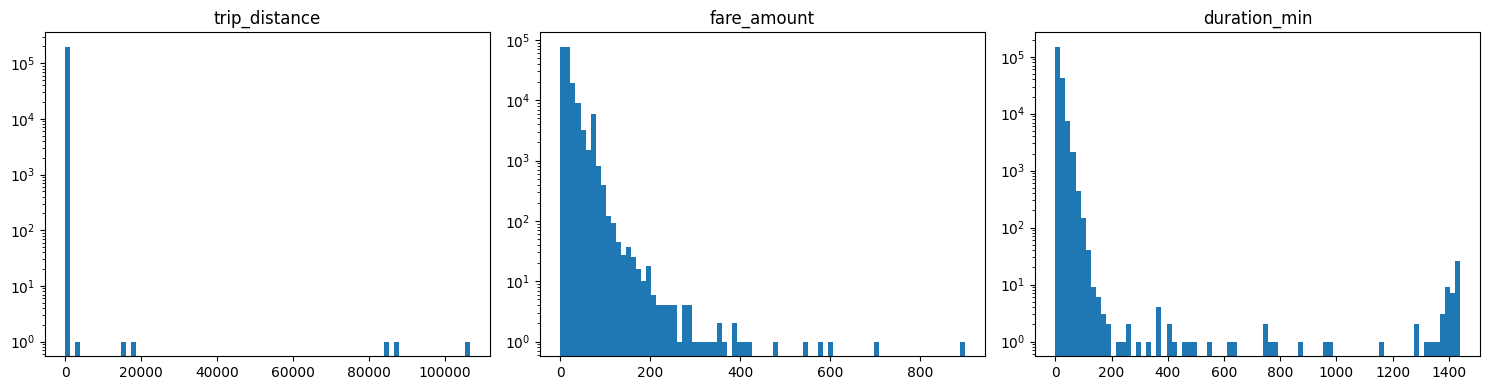

In [7]:
import matplotlib.pyplot as plt
import numpy as np

with duck.connect(settings) as con:
    sample = con.execute(f'''
        SELECT trip_distance, fare_amount,
               date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime)/60.0
                   AS duration_min
        FROM {duck.scan(path, hive=False)}
        USING SAMPLE reservoir(200000 ROWS) REPEATABLE (42)
    ''').df()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['trip_distance', 'fare_amount', 'duration_min']):
    values = sample[col].replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values > 0]
    ax.hist(values, bins=80, log=True)
    ax.set_title(col)
fig.tight_layout()


## Conclusions to carry into the contract

Write the outcome here as prose, then edit `contracts/trips.yml`:

- thresholds confirmed / adjusted (with the percentile that justified it)
- `threshold_basis` updated for each one changed
- any new drift case the resolver must absorb

Then re-ingest: a changed contract fingerprint forces re-ingestion of
every month, which is the intended behaviour.
